# note 
for loan limit if income was not imputed loan limit = income + credit score and must be smaller thant loan amount 

# Business problem:
tvjrnvrnvirvorevmredocvm

# advantage 
jnvinc
# ML problem type 
jci#
# hypothese 
- Higher debt-to-income ratios may increase default risk
- Lower credit scores may correlate with higher defaults
- High LTV loans may be riskier
- Certain loan purposes may have elevated default rates

# import library

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# function definition

In [2]:
#function to make data exploration for numeric features 
def num_eda(df,column,bin="auto"):
    # print basic stats
    print(df[column].describe())
    # plot histogram
    plt.figure(figsize=(10,8))
    df[column].hist(bins=bin)
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()


    # plot boxplot
    plt.figure(figsize=(10,8))
    sns.boxplot(x=df[column])
    plt.title(f'{column} Boxplot')
    plt.show()


# Import dataset 

In [3]:

# df=pd.read_csv("Loan_Default.csv")
df = pd.read_csv("../data/Loan_Default.csv")

<!-- ## data exploration  -->

# Data Exploration

In [4]:
# look at the general info on the dataset 
print (df.shape)
print(df.info())

(148670, 34)
<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            

* this part show that we have a dataset of 33 columns and 148670, but some column have less non null values , which mean that the data set have missing values in several columns .
* the dataset contain also several columns  of different data type, it have 21 string columns, 4 integer colums and 8 float columns

In [5]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


* this part show basic stats about the dataset 

In [ ]:
# check for missing values 
print(df.isna().sum())

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

+ part show the number of missing values each column have.
this is usefull as most machine learning model do not work properly with dataset that have missing value , handling these values become crucial 

<Axes: >

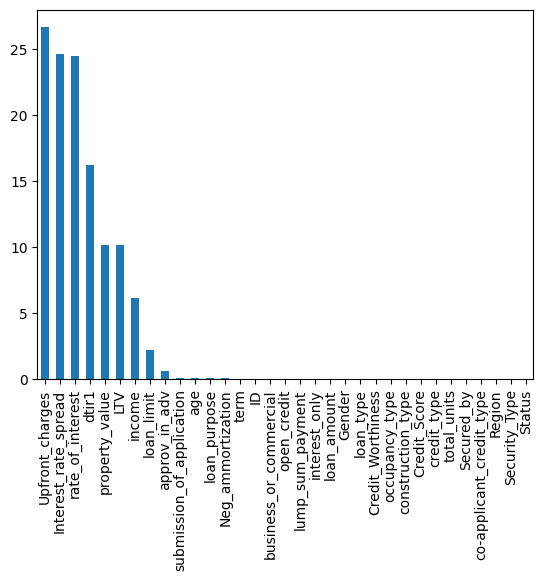

In [ ]:
# make a visualisation which illustrate the percentage of missing value per columns
missing = df.isnull().mean().sort_values(ascending=False)*100
missing.plot(kind='bar')

* using a graph to illustrate the percentage of missing values each column have gives a clearer idea on how to handle the missing values without making the dataset too bias 
* for example column upfront_charges will be drop as it contain over 25% of its value missing  

* **Status**

In [ ]:
df["Status"].unique()# confirm that there is only 2 posible status 


array([1, 0])

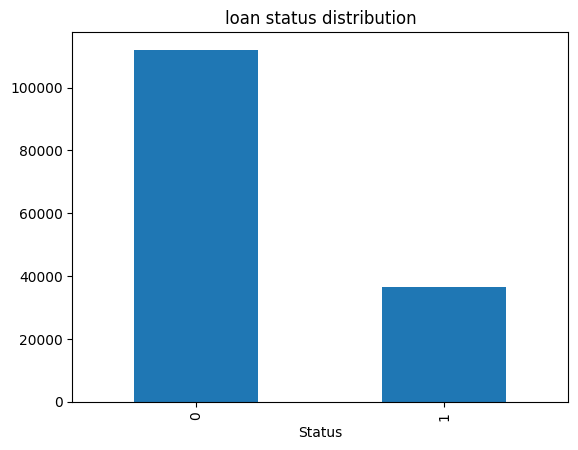

In [ ]:

df["Status"].value_counts(dropna=False).plot(kind="bar")
plt.title("loan status distribution")
plt.show()

* this graph show that the dataset we are using is imbalance 

* **ID**

In [5]:
# make sure their are no duplicate loans in the data set 
print(df["ID"].duplicated().sum())

0


* **Year**

In [6]:
# check the maximum and the minimum year to check if there is any erros.
# result show that there is only one year which is 2019 so the column year is useless for our prediction
print(df["year"].max())
print(df["year"].min())
print(df["year"].unique())

2019
2019
[2019]


In [7]:
df=df.drop(columns="year")

Index(['ID', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

* **Loan limit**

In [8]:
print(df["loan_limit"].unique())

<StringArray>
['cf', nan, 'ncf']
Length: 3, dtype: str


Text(0.5, 1.0, 'loan limit distribution')

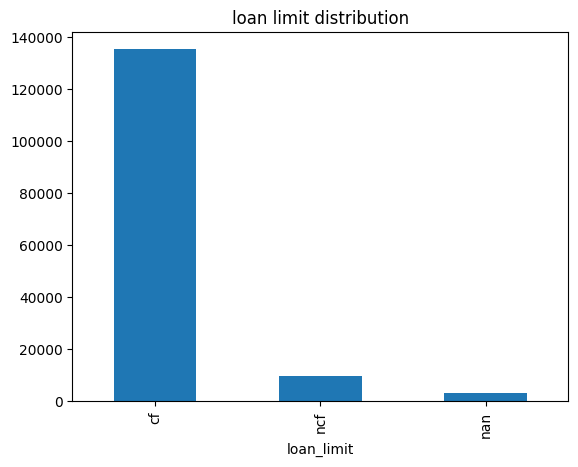

In [16]:
df["loan_limit"].value_counts(dropna=False).plot(kind="bar")
plt.title("loan limit distribution")
# plt.show()

In [10]:
df.columns

Index(['ID', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='str')

* **Income**

count    139520.000000
mean       6957.338876
std        6496.586382
min           0.000000
25%        3720.000000
50%        5760.000000
75%        8520.000000
max      578580.000000
Name: income, dtype: float64


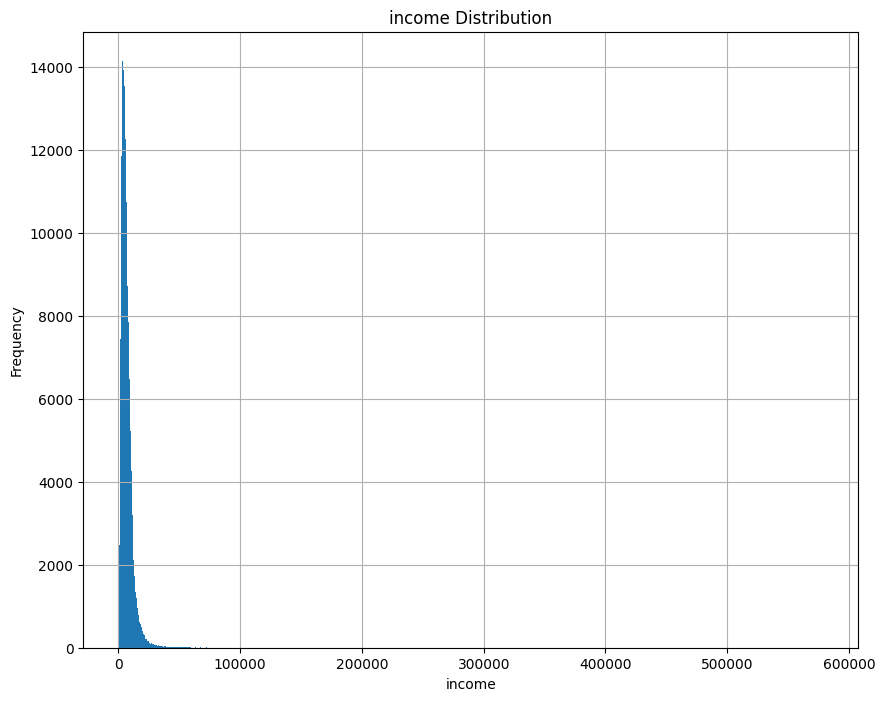

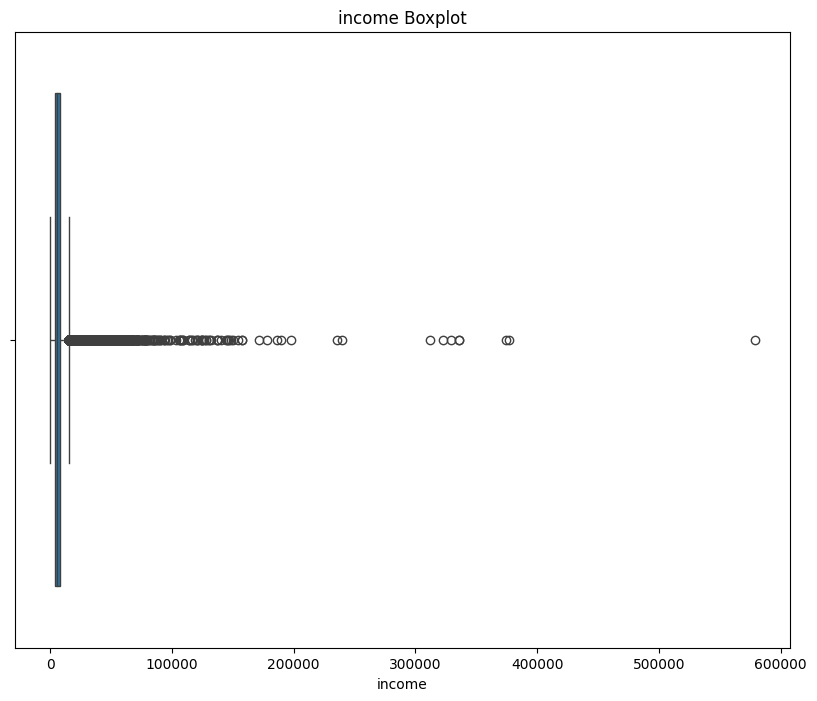

In [60]:
num_eda(df,"income")

**Basic stat**
* this show that income distribution apppear to be right skewed and have a hight variability
* the large difference between the mean and the meadian suggest the presence of outlier 
* also although 75% of the income are below 8520 the maximun income is 578580, this inducate strong outlier 

**Histogram**

* the histogram confirm that income is positively skewed  
* most income are concentrated closer to the lower income range

**boxplot**

* the box plot confirm that income have strongs outliers 

**Summary:**

+ The income distribution is highly right-skewed and have significant outliers, this suggest  that a small number of borrowers have an extrimely high income. 

**what are the problem:**
* the model might overfit rare high incomes ( that is if only  5 people have high income and did not default the model might just interpret it as high income always mean safe loan  )
* the mean is distorted by outliers 
* less than 10% missing values 
**Proposed solution**
* log transformation of the income 
* impute missing values using median
* add a missing income indicator as missing income might be  predictive, that is  borrower hiding their income may be higher risk.




* **Loan amount**

count    139520.000000
mean       6957.338876
std        6496.586382
min           0.000000
25%        3720.000000
50%        5760.000000
75%        8520.000000
max      578580.000000
Name: income, dtype: float64


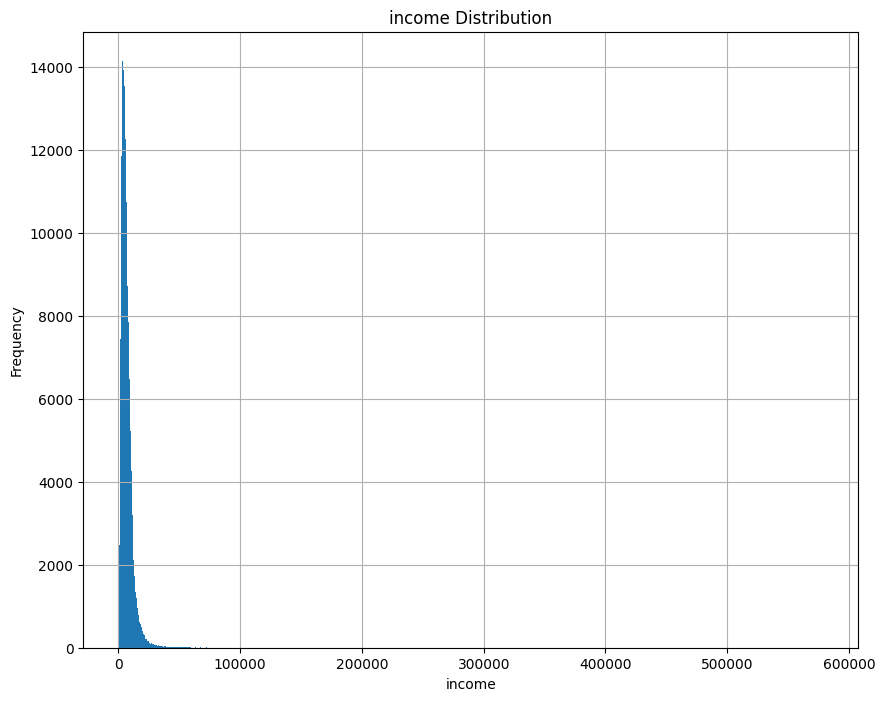

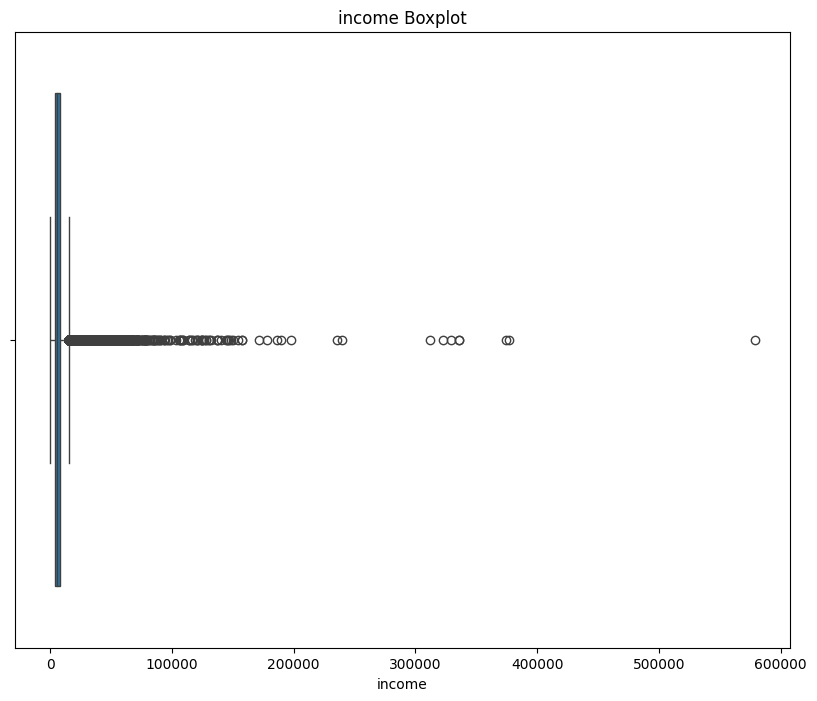

In [61]:
num_eda(df,"income")

# Credit_Score

count    148670.000000
mean        699.789103
std         115.875857
min         500.000000
25%         599.000000
50%         699.000000
75%         800.000000
max         900.000000
Name: Credit_Score, dtype: float64


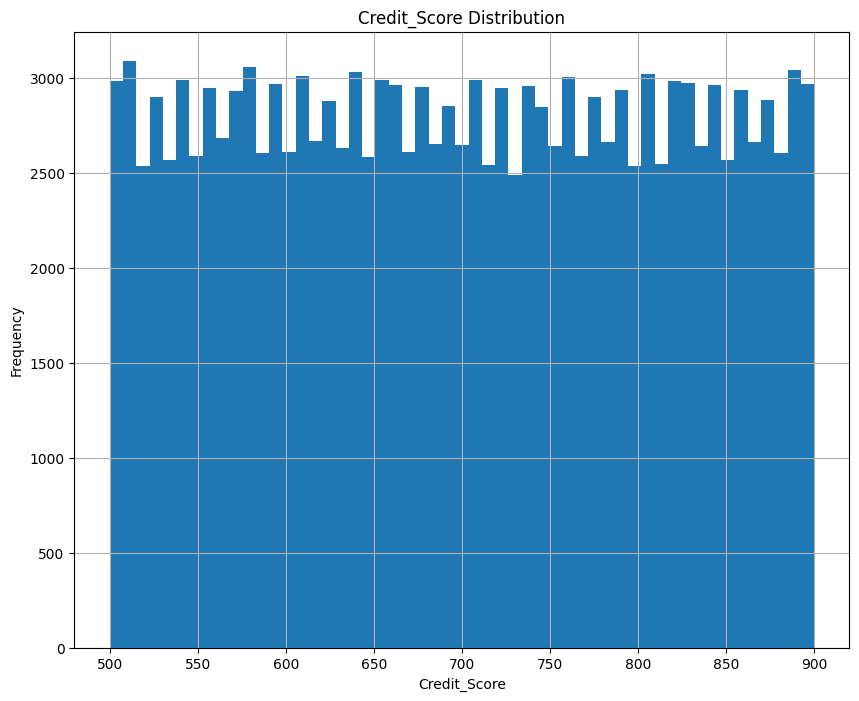

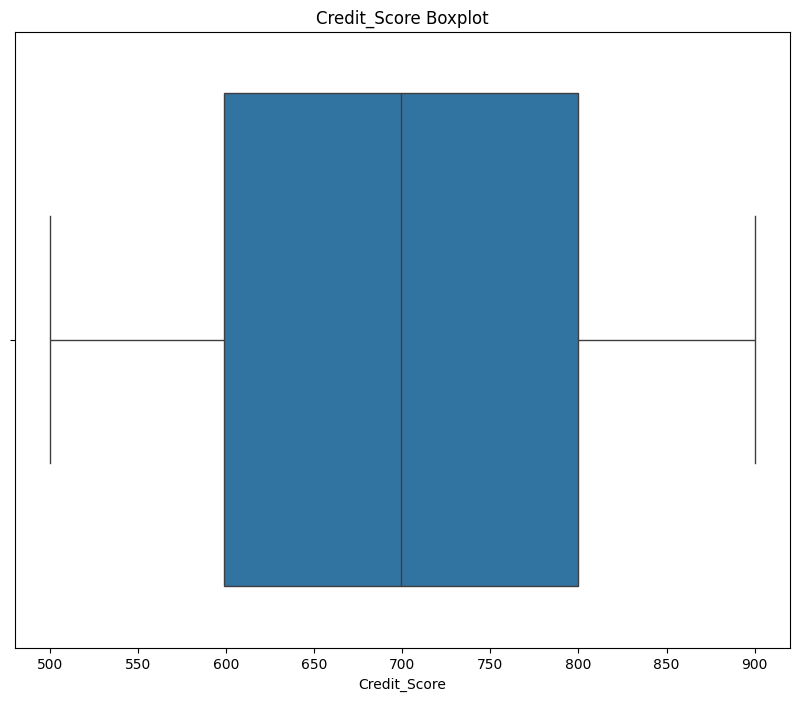

In [74]:
num_eda(df,"Credit_Score")

# rate_of_interest

count    112231.000000
mean          4.045476
std           0.561391
min           0.000000
25%           3.625000
50%           3.990000
75%           4.375000
max           8.000000
Name: rate_of_interest, dtype: float64


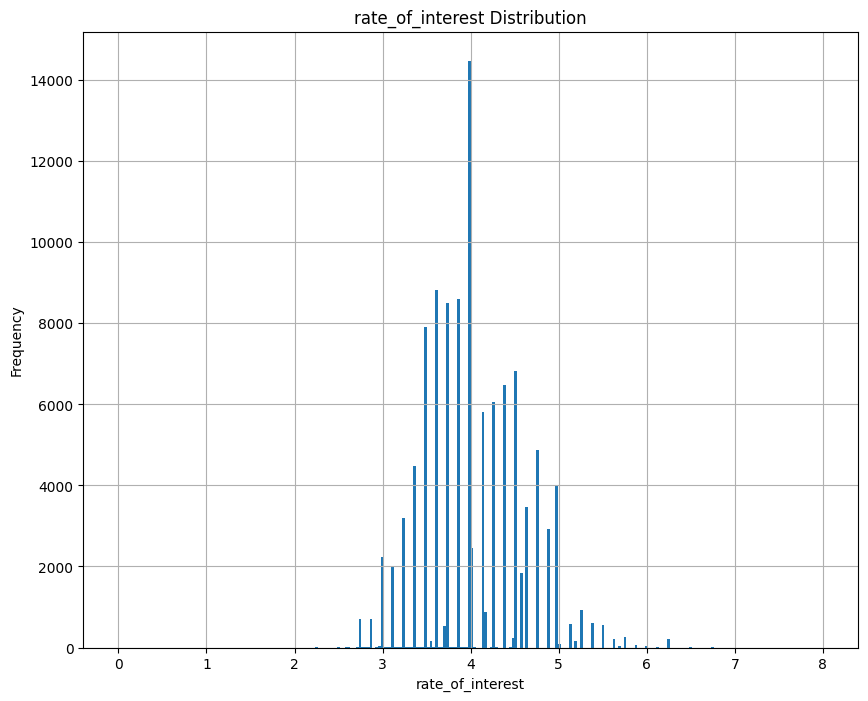

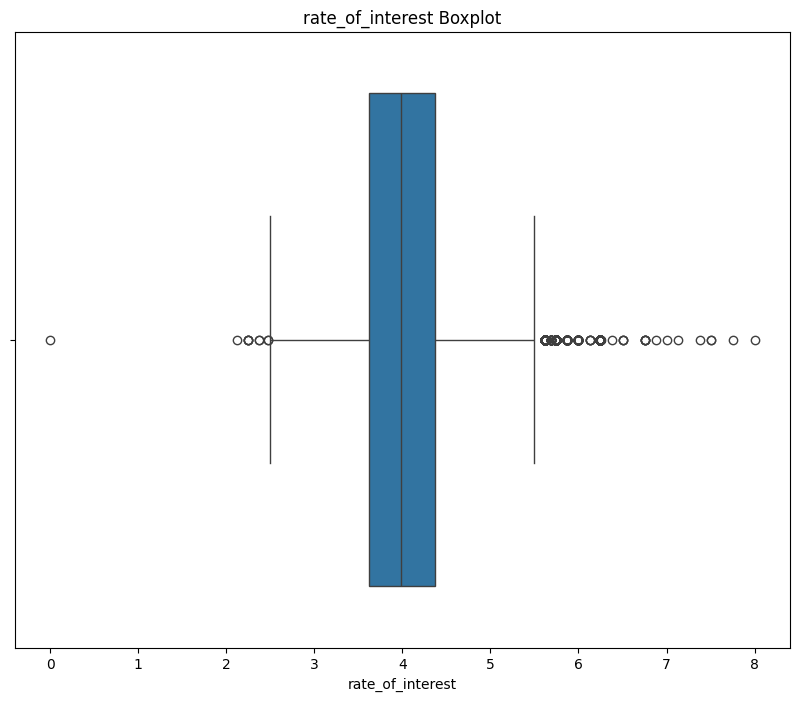

In [82]:
num_eda(df,"rate_of_interest")

# Interest_rate_spread

count    112031.000000
mean          0.441656
std           0.513043
min          -3.638000
25%           0.076000
50%           0.390400
75%           0.775400
max           3.357000
Name: Interest_rate_spread, dtype: float64


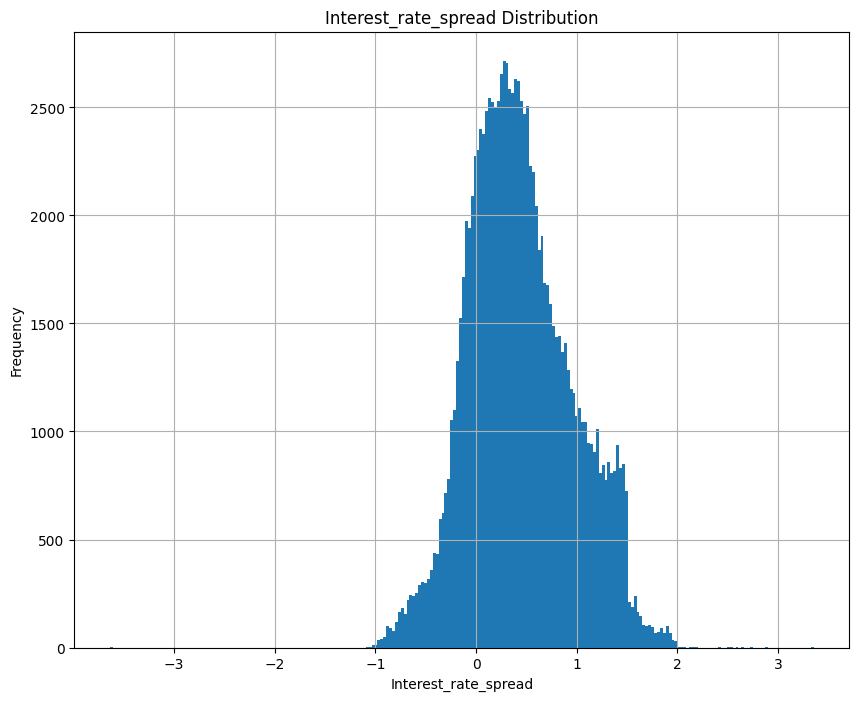

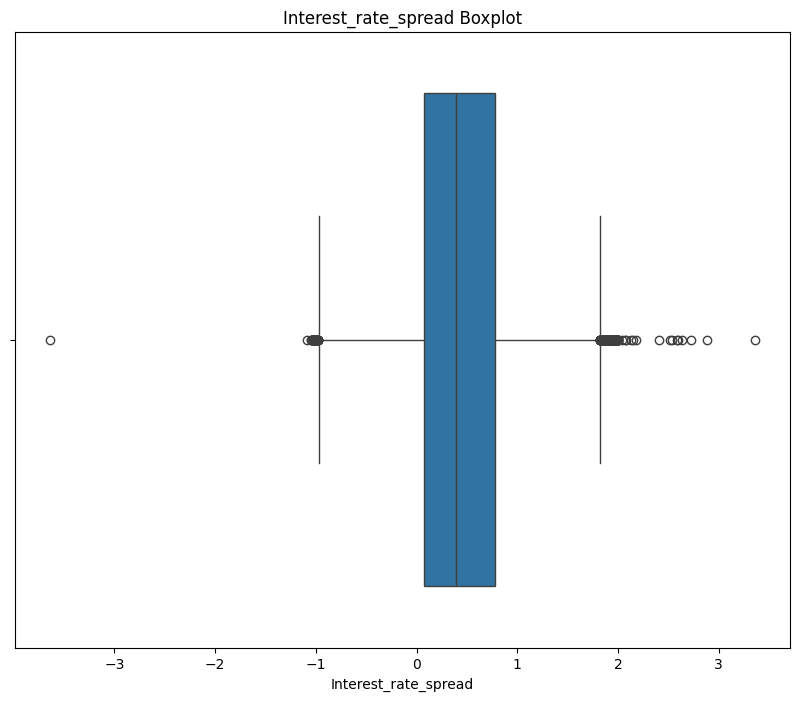

In [83]:
num_eda(df,"Interest_rate_spread")

# Upfront_charges

count    109028.000000
mean       3224.996127
std        3251.121510
min           0.000000
25%         581.490000
50%        2596.450000
75%        4812.500000
max       60000.000000
Name: Upfront_charges, dtype: float64


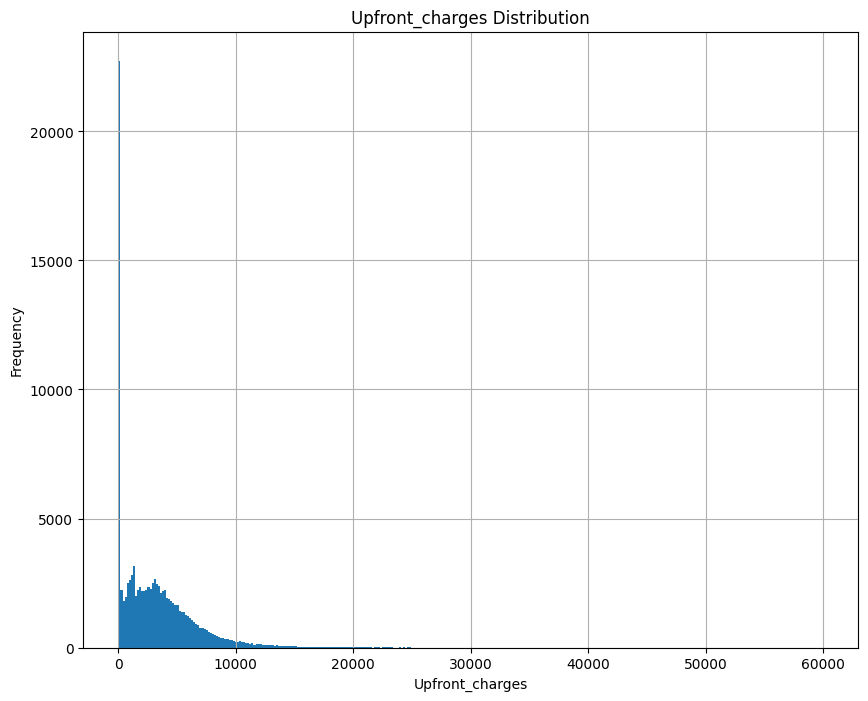

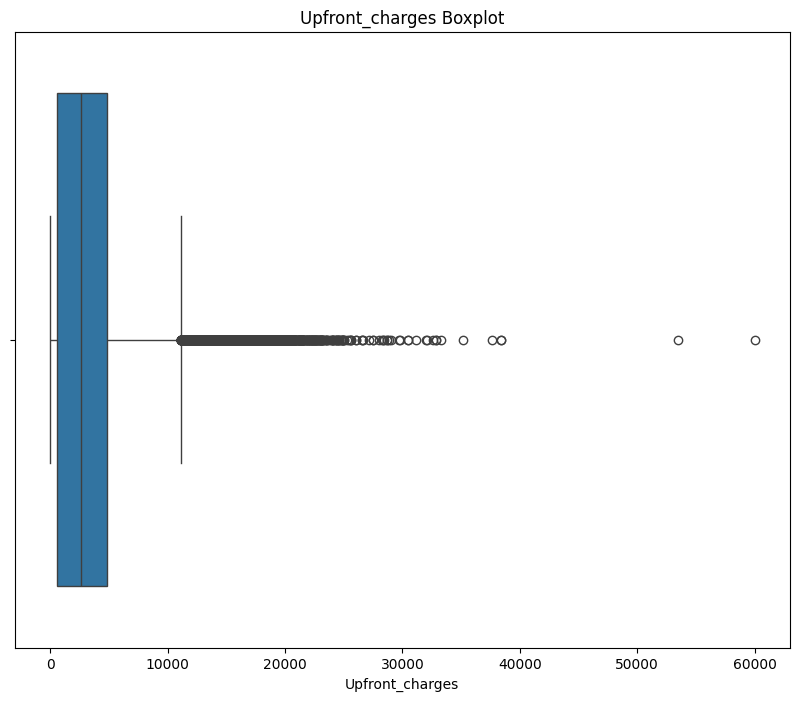

In [84]:
num_eda(df,"Upfront_charges")

# term

count    148629.000000
mean        335.136582
std          58.409084
min          96.000000
25%         360.000000
50%         360.000000
75%         360.000000
max         360.000000
Name: term, dtype: float64


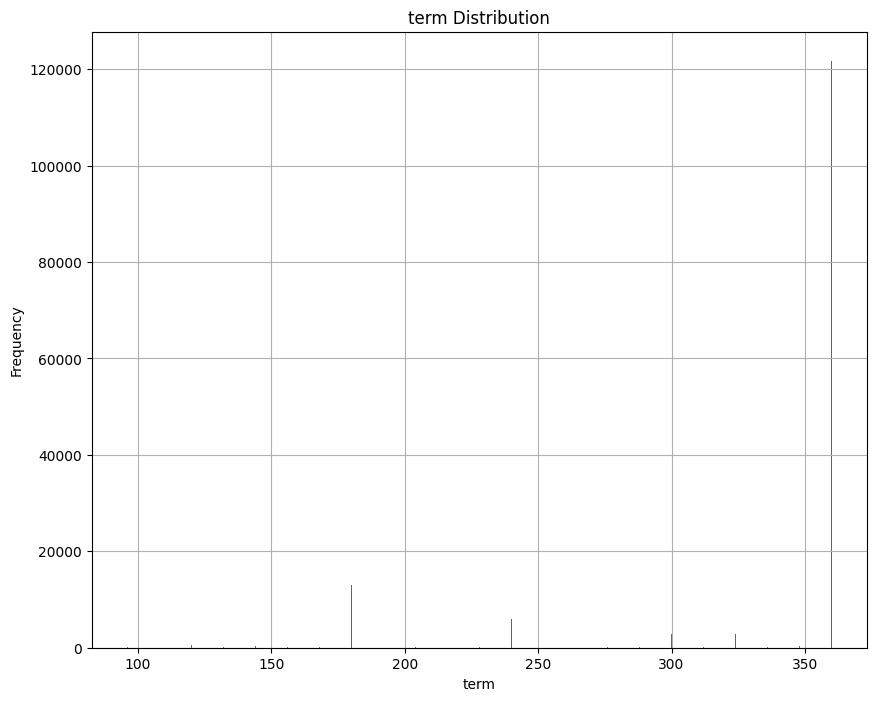

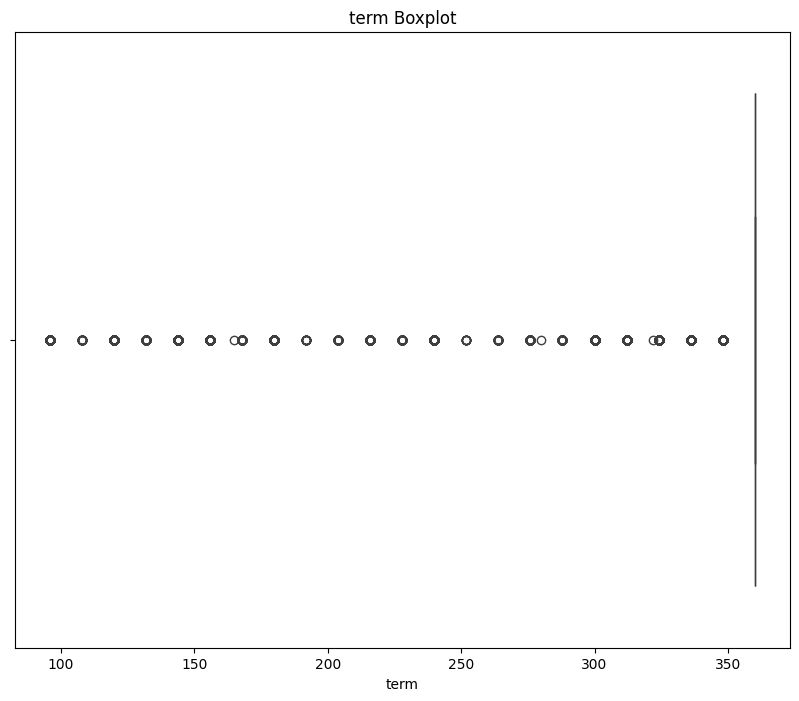

In [85]:
num_eda(df,"term")

# property_value

count    1.335720e+05
mean     4.978935e+05
std      3.599353e+05
min      8.000000e+03
25%      2.680000e+05
50%      4.180000e+05
75%      6.280000e+05
max      1.650800e+07
Name: property_value, dtype: float64


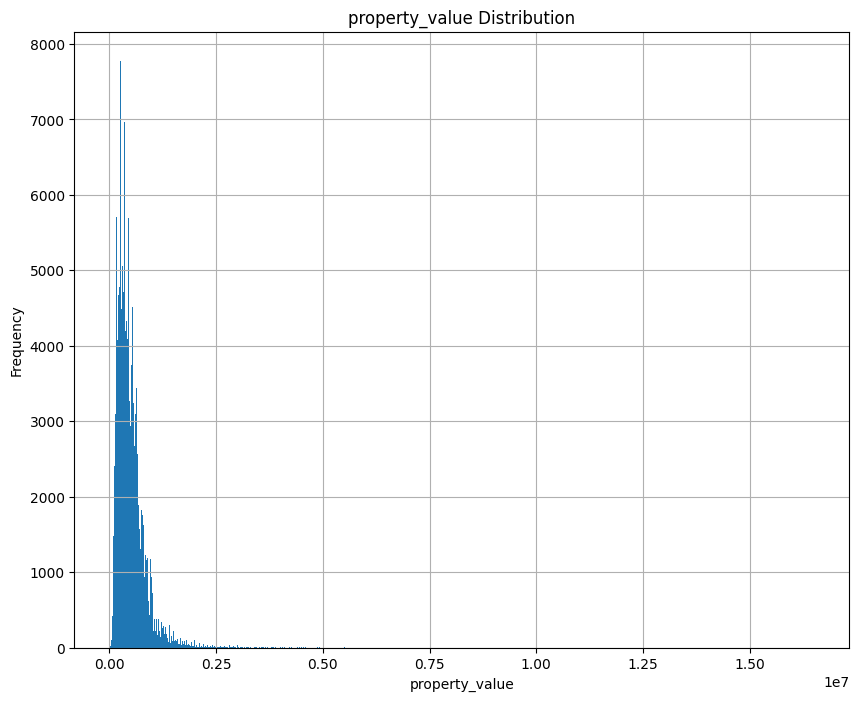

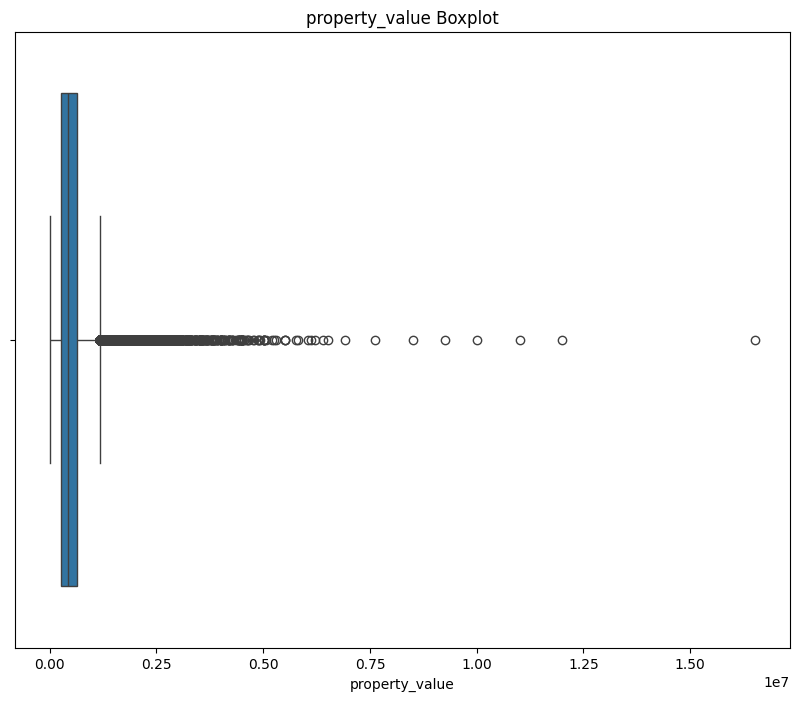

In [92]:
num_eda(df,"property_value")

# LTV

count    133572.000000
mean         72.746457
std          39.967603
min           0.967478
25%          60.474860
50%          75.135870
75%          86.184211
max        7831.250000
Name: LTV, dtype: float64


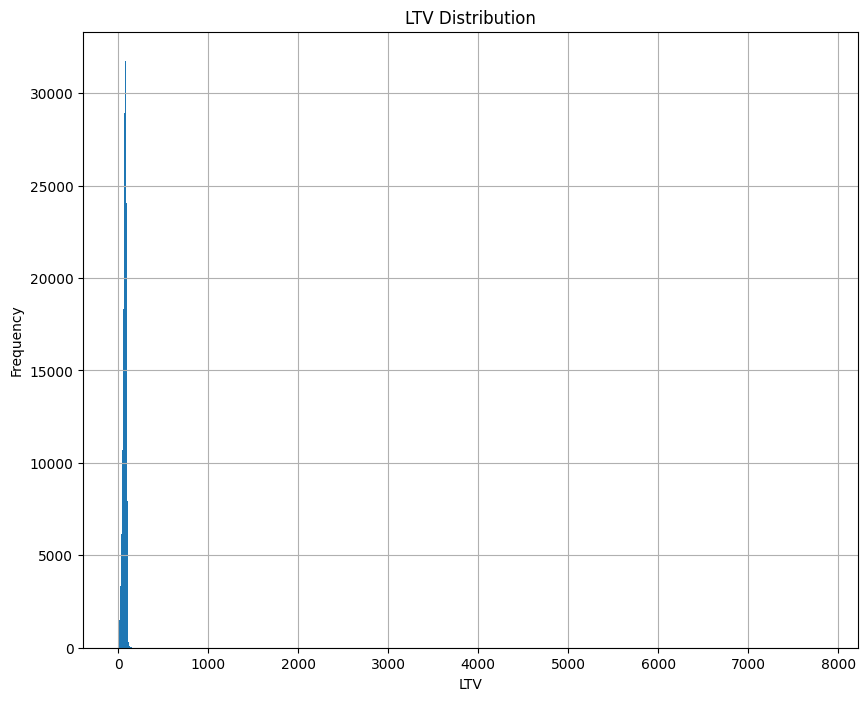

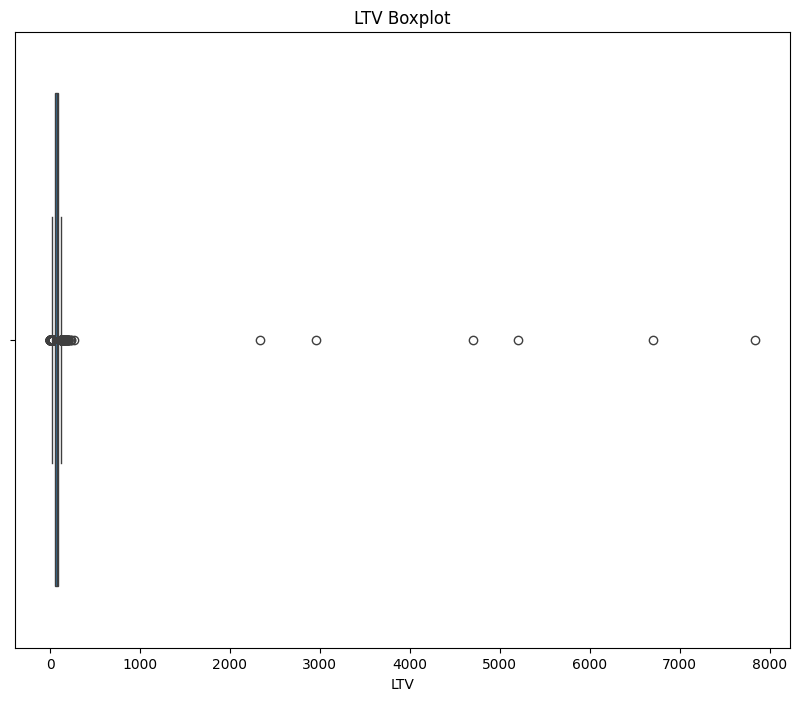

In [93]:
num_eda(df,"LTV")

In [ ]:
num_eda(df,"rate_of_interest")

In [ ]:
num_eda(df,"rate_of_interest")

In [ ]:
num_eda(df,"rate_of_interest")

In [81]:
df.select_dtypes(include="number").columns

Index(['ID', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1', 'l_l'],
      dtype='str')

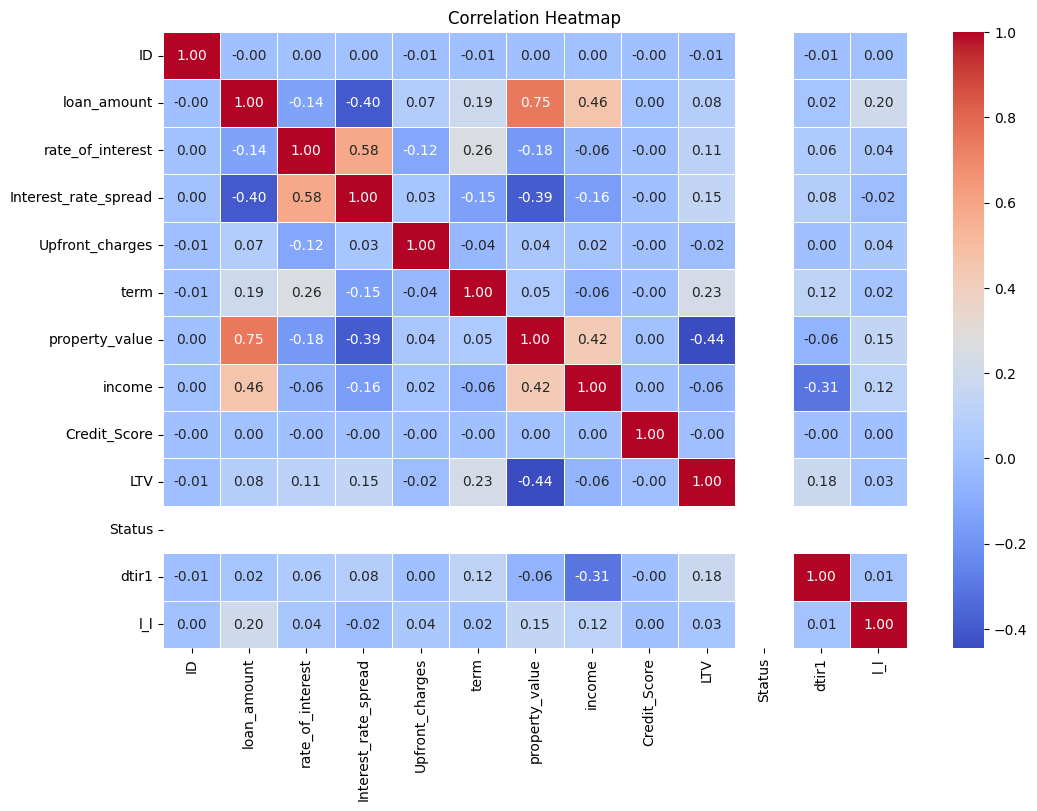

In [49]:
df["l_l"] = df["loan_limit"].apply(lambda x: 0 if x == "cf" else 1)
# Compute correlation matrix
corr = df.dropna().corr(numeric_only=True)

# Create figure
plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    corr,
    annot=True,       # show correlation values
    cmap="coolwarm",  # color palette
    fmt=".2f",        # decimal formatting
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# question to investigate 
Do larger loans default more?

Do higher interest rates increase defaults?

Does LTV affect risk?